# Theory Notebook I — Kinetic Plasma Dynamics and the Vlasov Equation

// for sections 0–3 na abstract lang

For sections 0-3, it builds the assumptions of the Vlasov model before introducing the equation, derives the Debye length and plasma parameter from the screening problem, and connects the microscopic many-particle description to collisionless phase-space transport. The emphasis is on the physical ordering required for a neutral plasma to support Langmuir oscillations under the Vlasov–Poisson model.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
eps0 = 8.8541878128e-12   # vacuum permittivity, F m^{-1}
kB = 1.380649e-23         # Boltzmann constant, J K^{-1}
e = 1.602176634e-19       # elementary charge, C
me = 9.1093837015e-31     # electron mass, kg

plt.rcParams.update({
    "figure.dpi": 140,
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
})


## §0. The Plasma Medium and the Ordering Behind the Vlasov Model

The Vlasov equation describes a weakly coupled plasma in the mean-field limit. Its domain is narrower than the phrase “ionized gas” suggests. A gas may contain free charges and still fail to behave as a plasma if collisions with neutrals or binary encounters between particles dominate the motion. The relevant distinction is collective response: a displacement of charge modifies the electric field, and that field acts back on a large number of particles before isolated collisions can erase the disturbance.

The electrostatic part of this collective response is fixed by Gauss’s law. For an electron-ion plasma with singly charged ions, the charge density is

$$
\rho(\mathbf r,t)=e n_i(\mathbf r,t)-e n_e(\mathbf r,t),
$$

where $e>0$ is the magnitude of the electron charge, $n_i$ is the ion number density, and $n_e$ is the electron number density. The electric potential satisfies

$$
\nabla^2\phi(\mathbf r,t)=-\frac{\rho(\mathbf r,t)}{\varepsilon_0},
\qquad 
\mathbf E=-\nabla \phi .
$$

A homogeneous plasma with $n_e=n_i=n_0$ produces no macroscopic electric field. Neutrality is a physical requirement; in the absence of a compensating positive background, an electron cloud carries net space charge, generates a macroscopic self-field, and does not admit a spatially uniform equilibrium state about which small electrostatic oscillations may be consistently linearized.

The first intrinsic plasma length follows from the static shielding problem. Take the ions as fixed on the electron response time, with $n_i=n_0$, and perturb the electrons by a small electrostatic potential $\phi$. In a thermalized electron population at temperature $T_e$, the electron density follows the Boltzmann factor associated with electron potential energy $-e\phi$:

$$
n_e=n_0\exp\!\left(\frac{e\phi}{k_B T_e}\right).
$$

The weak-field condition $|e\phi|\ll k_B T_e$ gives

$$
n_e
=n_0\left[1+\frac{e\phi}{k_B T_e}
+O\!\left(\frac{e^2\phi^2}{k_B^2T_e^2}\right)\right].
$$

To first order,

$$
\rho
=e(n_0-n_e)
\simeq
-\frac{n_0 e^2}{k_B T_e}\phi .
$$

Substitution into Poisson’s equation gives

$$
\nabla^2\phi
=\frac{n_0 e^2}{\varepsilon_0 k_B T_e}\phi .
$$

Writing the coefficient as $1/\lambda_D^2$ defines the Debye length,

$$
\boxed{
\lambda_D=
\left(\frac{\varepsilon_0 k_B T_e}{n_0e^2}\right)^{1/2}
}
$$

so the linearized shielding equation becomes

$$
\nabla^2\phi-\frac{\phi}{\lambda_D^2}=0
$$

away from the inserted test charge. With a point charge $Q$ at the origin, the solution is the screened Coulomb potential

$$
\phi(r)=\frac{Q}{4\pi\varepsilon_0 r}\exp\!\left(-\frac{r}{\lambda_D}\right).
$$

The formula shows the balance built into $\lambda_D$. Higher temperature weakens screening because thermal motion resists electron accumulation. Higher density strengthens screening because more charges are available to polarize around the perturbation.

The same length scale determines whether the collective description is statistically meaningful. Screening is produced by particles contained in a Debye sphere. The expected number of particles in that volume is

$$
N_D=\frac{4\pi}{3}n_0\lambda_D^3 .
$$

Many plasma texts use the order-of-magnitude plasma parameter

$$
\boxed{\Lambda=n_0\lambda_D^3}
$$

and absorb $4\pi/3$ into convention. The condition

$$
\Lambda\gg1
$$

is stronger than the statement that the gas is ionized. It states that shielding is a many-particle effect. Relative number fluctuations inside a Debye sphere scale as

$$
\frac{\delta N_D}{N_D}\sim\frac{1}{\sqrt{N_D}},
$$

so the smooth field becomes well defined when $N_D$ is large. The same ordering is also weak coupling. The Coulomb energy of two elementary charges separated by $\lambda_D$ is

$$
U_D=\frac{e^2}{4\pi\varepsilon_0\lambda_D},
$$

and division by the thermal energy gives

$$
\frac{U_D}{k_BT_e}
=
\frac{e^2}{4\pi\varepsilon_0\lambda_D k_BT_e}
=
\frac{1}{4\pi n_0\lambda_D^3}
=
\frac{1}{4\pi\Lambda}.
$$

Thus $\Lambda\gg1$ is equivalent, up to constants, to weak electrostatic coupling at the screening scale. Individual close encounters remain present, but they are not the leading mechanism over the electron collective time.

The corresponding time scale is the electron plasma frequency. If the electron fluid is displaced a small distance $\xi$ relative to a fixed ion background, the separation creates charge sheets. Gauss’s law gives the restoring field magnitude

$$
E=\frac{e n_0 \xi}{\varepsilon_0}.
$$

The electron equation of motion is

$$
m_e\frac{d^2\xi}{dt^2}=-eE
=-\frac{n_0e^2}{\varepsilon_0}\xi .
$$

Hence

$$
\frac{d^2\xi}{dt^2}+\omega_{pe}^2\xi=0,
\qquad
\boxed{
\omega_{pe}=
\left(\frac{n_0e^2}{\varepsilon_0 m_e}\right)^{1/2}
}.
$$

The ion background is immobile on this time scale to leading order because $m_i\gg m_e$, so the ion plasma frequency is smaller by $(m_e/m_i)^{1/2}$. The neutral plasma specified in the project is therefore the equilibrium state in which fast electron oscillations have a restoring force but no net space-charge acceleration.

The Vlasov ordering used in the following sections is consequently

$$
L\gg\lambda_D,\qquad
\Lambda\gg1,\qquad
\nu_{\mathrm{coll}}\ll\omega_{pe},
$$

where $L$ is a macroscopic length and $\nu_{\mathrm{coll}}$ is a collisional relaxation rate. Under this ordering the plasma remains quasineutral on large scales, but small deviations from neutrality generate the electrostatic fields responsible for Langmuir waves.

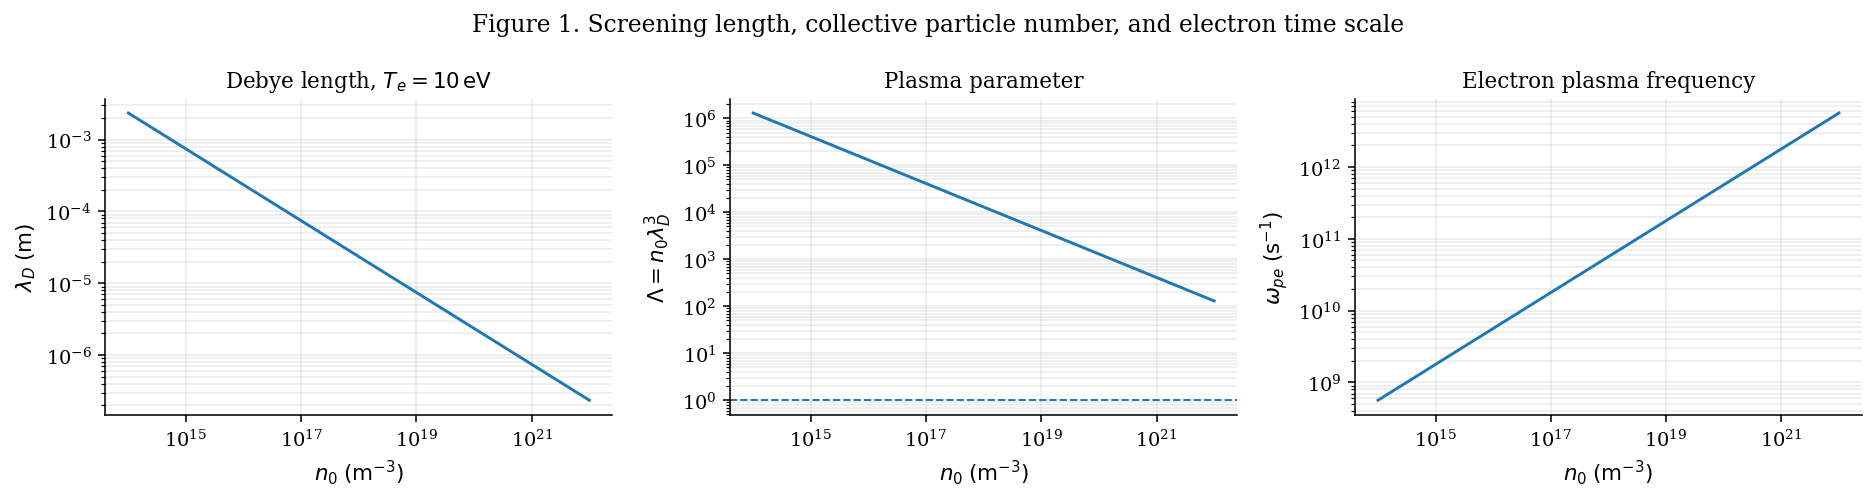

At n0 = 1.0e+18 m^-3 and Te = 10.0 eV:
lambda_D = 2.351e-05 m
Lambda   = 1.299e+04
omega_pe = 5.641e+10 s^-1


In [2]:
Te_eV = 10.0
Te = Te_eV * 11604.51812
n0 = np.logspace(14, 22, 700)

lambda_D = np.sqrt(eps0 * kB * Te / (n0 * e**2))
Lambda = n0 * lambda_D**3
omega_pe = np.sqrt(n0 * e**2 / (eps0 * me))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))

axes[0].loglog(n0, lambda_D)
axes[0].set_xlabel(r"$n_0\;(\mathrm{m^{-3}})$")
axes[0].set_ylabel(r"$\lambda_D\;(\mathrm{m})$")
axes[0].set_title(r"Debye length, $T_e=10\,\mathrm{eV}$")
axes[0].grid(True, which="both", alpha=0.25)

axes[1].loglog(n0, Lambda)
axes[1].axhline(1, linestyle="--", linewidth=1)
axes[1].set_xlabel(r"$n_0\;(\mathrm{m^{-3}})$")
axes[1].set_ylabel(r"$\Lambda=n_0\lambda_D^3$")
axes[1].set_title("Plasma parameter")
axes[1].grid(True, which="both", alpha=0.25)

axes[2].loglog(n0, omega_pe)
axes[2].set_xlabel(r"$n_0\;(\mathrm{m^{-3}})$")
axes[2].set_ylabel(r"$\omega_{pe}\;(\mathrm{s^{-1}})$")
axes[2].set_title("Electron plasma frequency")
axes[2].grid(True, which="both", alpha=0.25)

fig.suptitle("Figure 1. Screening length, collective particle number, and electron time scale")
fig.tight_layout()
plt.show()

n_check = 1e18
lambda_check = np.sqrt(eps0 * kB * Te / (n_check * e**2))
Lambda_check = n_check * lambda_check**3
omega_check = np.sqrt(n_check * e**2 / (eps0 * me))

print(f"At n0 = {n_check:.1e} m^-3 and Te = {Te_eV:.1f} eV:")
print(f"lambda_D = {lambda_check:.3e} m")
print(f"Lambda   = {Lambda_check:.3e}")
print(f"omega_pe = {omega_check:.3e} s^-1")


**Figure 1. Screening length, collective particle number, and electron time scale**

Figure 1 summarizes the density dependence of the principal electrostatic scales at fixed electron temperature $T_e=10\,\mathrm{eV}$. Only relations needed for later kinetic modeling are emphasized.

The Debye length decreases with increasing density,

$$
\lambda_D=\left(\frac{\varepsilon_0 k_B T_e}{n_0 e^2}\right)^{1/2},
$$

so denser plasmas screen charge perturbations over shorter distances. This identifies the spatial scale below which charge separation may persist and above which quasineutrality is rapidly restored.

The plasma parameter,

$$
\Lambda=n_0\lambda_D^3,
$$

also decreases as $n_0^{-1/2}$ at fixed temperature, yet remains large throughout the plotted range. A large value of $\Lambda$ indicates that many particles participate in shielding, which supports the mean-field ordering required for the Vlasov model.

The electron plasma frequency increases with density,

$$
\omega_{pe}=\left(\frac{n_0 e^2}{\varepsilon_0 m_e}\right)^{1/2},
$$

and sets the characteristic timescale for rapid electron response. Higher density therefore corresponds to faster Langmuir-scale oscillations.

At the representative value $n_0=10^{18}\,\mathrm{m^{-3}}$,

$$
\lambda_D=2.35\times10^{-5}\,\mathrm{m},\qquad
\Lambda=1.30\times10^4,\qquad
\omega_{pe}=5.64\times10^{10}\,\mathrm{s^{-1}}.
$$

These values place the system in a strongly collective and weakly coupled regime appropriate for collisionless kinetic analysis.


## §1. Distribution Function in Phase Space

The ordering above removes the need to follow individual Coulomb encounters, but it does not justify a fluid model by itself. Langmuir waves and collisionless damping depend on how particles are distributed in velocity space. A description retaining velocity information is therefore required.

For one given particle, the kinetic state is represented by a distribution function $f(\mathbf r,\mathbf v,t)$ on the six-dimensional phase space. It is defined by

$$
dN=f(\mathbf r,\mathbf v,t)\,d^3r\,d^3v,
$$

so that $dN$ is the number of particles in a spatial element $d^3r$ centered at $\mathbf r$ and a velocity-space element $d^3v$ centered at $\mathbf v$. Since $d^3v$ has units $\mathrm{m^3s^{-3}}$, the dimensions of $f$ are

$$
[f]=\mathrm{m^{-3}}(\mathrm{m\,s^{-1}})^{-3}
=\mathrm{s^3m^{-6}} .
$$

In kinetic theory, $\mathbf r$ and $\mathbf v$ are independent variables. A single particle trajectory has $\mathbf r=\mathbf r(t)$ and $\mathbf v=\dot{\mathbf r}(t)$; a distribution function is instead a field over all possible positions and velocities at a given time. This distinction is essential because acceleration changes the occupancy of velocity space, not only the density in physical space.

The connection with fluid quantities is made through moments. The number density is

$$
n(\mathbf r,t)=\int_{\mathbb R^3} f(\mathbf r,\mathbf v,t)\,d^3v.
$$

The mean flow velocity is

$$
\mathbf u(\mathbf r,t)
=
\frac{1}{n(\mathbf r,t)}
\int_{\mathbb R^3}\mathbf v f(\mathbf r,\mathbf v,t)\,d^3v.
$$

The pressure tensor is

$$
P_{ij}(\mathbf r,t)
=
m\int_{\mathbb R^3}
\big(v_i-u_i\big)\big(v_j-u_j\big)
f(\mathbf r,\mathbf v,t)\,d^3v .
$$

Fluid theory retains a finite number of these moments and then closes the hierarchy by assumption. Kinetic theory keeps the distribution itself, and therefore retains the information needed to describe velocity-space resonances and non-Maxwellian structure.

For a spatially homogeneous electron equilibrium with no drift, the appropriate background distribution is the Maxwellian

$$
f_0(\mathbf v)
=
n_0
\left(\frac{m_e}{2\pi k_B T_e}\right)^{3/2}
\exp\!\left(-\frac{m_e|\mathbf v|^2}{2k_B T_e}\right).
$$

The normalization follows from the Gaussian integral

$$
\int_{-\infty}^{\infty}
\exp\!\left(-\frac{m_ev_x^2}{2k_BT_e}\right)\,dv_x
=
\left(\frac{2\pi k_BT_e}{m_e}\right)^{1/2}.
$$

Since the three velocity components factor,

$$
\int_{\mathbb R^3} f_0(\mathbf v)\,d^3v
=
n_0
\left(\frac{m_e}{2\pi k_B T_e}\right)^{3/2}
\left(\frac{2\pi k_B T_e}{m_e}\right)^{3/2}
=
n_0.
$$

The Maxwellian may also be obtained variationally. Maximizing the kinetic entropy

$$
S[f]=-k_B\int f\ln f\,d^3v
$$

subject to fixed particle density

$$
\int f\,d^3v=n_0
$$

and fixed kinetic energy density

$$
\int \frac12 m_ev^2 f\,d^3v=\frac32 n_0k_BT_e
$$

gives

$$
\delta\left[
-k_B\int f\ln f\,d^3v
-\alpha\int f\,d^3v
-\beta\int \frac12m_ev^2f\,d^3v
\right]=0.
$$

The coefficient of $\delta f$ must vanish:

$$
-k_B(\ln f+1)-\alpha-\frac{\beta m_ev^2}{2}=0.
$$

Thus

$$
f=A\exp(-Bv^2),
$$

with constants fixed by the two constraints. This gives the Maxwellian above with $B=m_e/(2k_BT_e)$. The equilibrium is uniform in space, isotropic in velocity, and stationary in time. It is the background distribution from which the small-amplitude electron density perturbations of Langmuir theory are constructed.

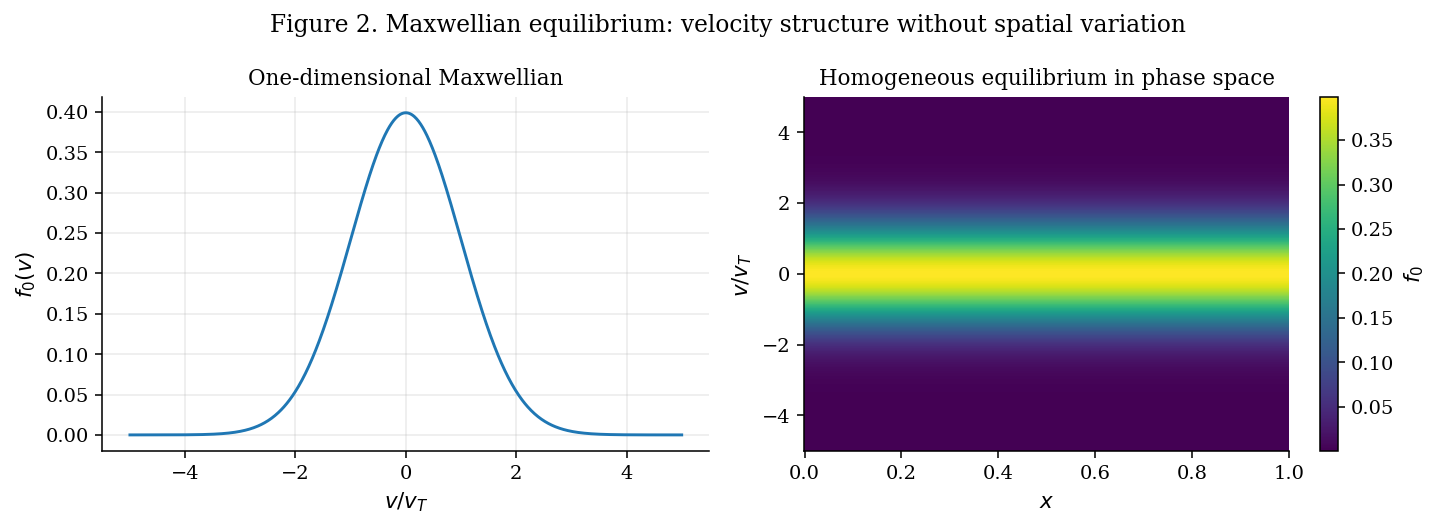

In [3]:
vT = 1.0
v = np.linspace(-5*vT, 5*vT, 800)
f1 = np.exp(-v**2/(2*vT**2)) / np.sqrt(2*np.pi*vT**2)

x = np.linspace(0, 1, 320)
X, V = np.meshgrid(x, v)
F = np.exp(-V**2/(2*vT**2)) / np.sqrt(2*np.pi*vT**2)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))

axes[0].plot(v/vT, f1)
axes[0].set_xlabel(r"$v/v_T$")
axes[0].set_ylabel(r"$f_0(v)$")
axes[0].set_title("One-dimensional Maxwellian")
axes[0].grid(alpha=0.25)

mesh = axes[1].pcolormesh(X, V/vT, F, shading="auto")
axes[1].set_xlabel(r"$x$")
axes[1].set_ylabel(r"$v/v_T$")
axes[1].set_title("Homogeneous equilibrium in phase space")
fig.colorbar(mesh, ax=axes[1], label=r"$f_0$")

fig.suptitle("Figure 2. Maxwellian equilibrium: velocity structure without spatial variation")
fig.tight_layout()
plt.show()


**Figure 2. Maxwellian equilibrium in velocity and phase space**

Figure 2 presents the equilibrium state used in the linearized Vlasov analysis.

The left panel shows the one-dimensional Maxwellian velocity distribution,

$$
f_0(v)=\frac{1}{\sqrt{2\pi}v_T}\exp\!\left(-\frac{v^2}{2v_T^2}\right),
$$

centered at zero velocity. The symmetry about $v=0$ indicates zero bulk drift, while the width is determined by the thermal speed $v_T$.

The right panel shows the same equilibrium in $(x,v)$ phase space. Because the state is spatially homogeneous, the distribution is independent of position and varies only with velocity. This provides the uniform background from which small electrostatic perturbations are introduced.


## §2. From Exact Particle Dynamics to the Vlasov Limit

The distribution function used in the Vlasov equation is the smooth limit of an exact microscopic density. For $N$ particles of a given species, with trajectories $\mathbf r_k(t)$ and velocities $\mathbf v_k(t)$, define the Klimontovich density

$$
\mathcal N(\mathbf r,\mathbf v,t)
=
\sum_{k=1}^{N}
\delta^{(3)}\!\big(\mathbf r-\mathbf r_k(t)\big)
\delta^{(3)}\!\big(\mathbf v-\mathbf v_k(t)\big).
$$

It is singular rather than smooth. Each particle contributes one spike at its instantaneous phase-space location. Integration over any phase-space region counts exactly how many particles lie in that region.

The equation for $\mathcal N$ follows directly from the chain rule. For one particle,

$$
\frac{\partial}{\partial t}
\delta^{(3)}(\mathbf r-\mathbf r_k(t))
=
-\dot{\mathbf r}_k(t)\cdot
\nabla_r\delta^{(3)}(\mathbf r-\mathbf r_k(t)),
$$

and

$$
\frac{\partial}{\partial t}
\delta^{(3)}(\mathbf v-\mathbf v_k(t))
=
-\dot{\mathbf v}_k(t)\cdot
\nabla_v\delta^{(3)}(\mathbf v-\mathbf v_k(t)).
$$

Applying the product rule to the two delta factors and summing over $k$,

$$
\frac{\partial \mathcal N}{\partial t}
=
-\sum_k
\dot{\mathbf r}_k\cdot\nabla_r
\left[
\delta^{(3)}(\mathbf r-\mathbf r_k)
\delta^{(3)}(\mathbf v-\mathbf v_k)
\right]
-\sum_k
\dot{\mathbf v}_k\cdot\nabla_v
\left[
\delta^{(3)}(\mathbf r-\mathbf r_k)
\delta^{(3)}(\mathbf v-\mathbf v_k)
\right].
$$

On the support of the $k$-th delta function, $\mathbf v=\mathbf v_k$. Newton’s equation gives

$$
\dot{\mathbf v}_k=\frac{\mathbf F_{\mathrm{exact}}(\mathbf r_k,t)}{m}.
$$

The exact microscopic density therefore satisfies

$$
\boxed{
\frac{\partial \mathcal N}{\partial t}
+\mathbf v\cdot\nabla_r\mathcal N
+\frac{\mathbf F_{\mathrm{exact}}}{m}\cdot\nabla_v\mathcal N
=0
}
$$

in the distributional sense. This is the Klimontovich equation: a Newtonian mechanics in phase-space conservation.

The smooth kinetic distribution is introduced by ensemble averaging or by coarse graining over volumes large compared with inter-particle spacing but small compared with macroscopic scales:

$$
f(\mathbf r,\mathbf v,t)=\langle \mathcal N(\mathbf r,\mathbf v,t)\rangle.
$$

Write the microscopic electric field and density as mean plus fluctuation,

$$
\mathbf E_{\mathrm{exact}}=\mathbf E+\delta\mathbf E,
\qquad
\mathcal N=f+\delta\mathcal N.
$$

Averaging the Klimontovich equation gives, for the electrostatic force $q\mathbf E_{\mathrm{exact}}$,

$$
\frac{\partial f}{\partial t}
+\mathbf v\cdot\nabla_r f
+\frac{q}{m}\mathbf E\cdot\nabla_v f
=
-\frac{q}{m}
\left\langle
\delta\mathbf E\cdot\nabla_v\delta\mathcal N
\right\rangle .
$$

The term on the right contains the correlation between microscopic field fluctuations and microscopic density fluctuations. Under weak-coupling closures it generates collisional kinetic operators, including Landau or Balescu--Lenard forms. It is absent only in the collisionless mean-field approximation.

The ordering $\Lambda\gg1$ supplies the approximation. Since many particles occupy a Debye sphere, fluctuations in the microscopic field are small compared with the averaged field at the collective scale. Collisional relaxation is slower than the electron plasma period, written schematically as

$$
\nu_{\mathrm{coll}}\ll\omega_{pe}.
$$

Neglecting the fluctuation-correlation term gives the Vlasov equation:

$$
\boxed{
\frac{\partial f}{\partial t}
+\mathbf v\cdot\nabla_r f
+\frac{q}{m}\mathbf E\cdot\nabla_v f=0
}.
$$

The electric field is generated by the same distribution that it accelerates. For an electron distribution $f_e$ and fixed ion background $n_i=n_0$,

$$
\rho=e n_0-e\int f_e\,d^3v,
$$

so Poisson’s equation gives

$$
\nabla\cdot\mathbf E=\frac{1}{\varepsilon_0}
\left(
e n_0-e\int f_e\,d^3v
\right),
\qquad
\mathbf E=-\nabla\phi.
$$

Equivalently,

$$
-\nabla^2\phi
=
\frac{e}{\varepsilon_0}
\left(
n_0-\int f_e\,d^3v
\right).
$$

The Vlasov equation together with this Poisson equation forms the Vlasov--Poisson system used for electrostatic Langmuir dynamics.

## §3. Liouville Structure and Collisionless Transport

Collisionless motion transports phase-space density along the characteristics generated by the Lorentz force.

For a particle of charge $q$ and mass $m$,

$$
\dot{\mathbf r}=\mathbf v,
\qquad
\dot{\mathbf v}
=
\frac{q}{m}
\left(
\mathbf E+\mathbf v\times\mathbf B
\right)
$$

with the six-dimensional coordinate:

$$
\mathbf w=(\mathbf r,\mathbf v),
\qquad
\dot{\mathbf w}=(\dot{\mathbf r},\dot{\mathbf v}).
$$

the phase-space divergence of this flow is

$$
\nabla_w\cdot\dot{\mathbf w}
=
\nabla_r\cdot\mathbf v
+
\nabla_v\cdot
\frac{q}{m}
\left(
\mathbf E+\mathbf v\times\mathbf B
\right).
$$

The first term vanishes because velocity is independent of the position coordinates:

$$
\nabla_r\cdot\mathbf v
=
\sum_{i=1}^{3}\frac{\partial v_i}{\partial r_i}
=0.
$$

The electric part of the second term vanishes because $\mathbf E=\mathbf E(\mathbf r,t)$ has no velocity dependence:

$$
\nabla_v\cdot\mathbf E
=
\sum_{i=1}^{3}\frac{\partial E_i}{\partial v_i}
=0.
$$

For the magnetic term, use $(\mathbf v\times\mathbf B)_i=\varepsilon_{ijk}v_jB_k$. Then

$$
\nabla_v\cdot(\mathbf v\times\mathbf B)
=
\frac{\partial}{\partial v_i}
\left(\varepsilon_{ijk}v_jB_k\right)
=
\varepsilon_{ijk}\delta_{ij}B_k
=
\varepsilon_{jjk}B_k
=0.
$$

Thus

$$
\boxed{
\nabla_w\cdot\dot{\mathbf w}=0
}.
$$

This is Liouville’s theorem for the nonrelativistic charged-particle flow: phase-space volume is preserved under Hamiltonian motion. A material element in phase space can stretch and shear, though not compressed.

Particle conservation in phase space is expressed by the continuity equation

$$
\frac{\partial f}{\partial t}
+
\nabla_w\cdot(f\dot{\mathbf w})=0 .
$$

Expanding the divergence,

$$
\frac{\partial f}{\partial t}
+
\dot{\mathbf w}\cdot\nabla_w f
+
f\,\nabla_w\cdot\dot{\mathbf w}
=0.
$$

Liouville’s theorem removes the last term, leaving

$$
\frac{\partial f}{\partial t}
+
\dot{\mathbf w}\cdot\nabla_w f=0.
$$

Substituting the equations of motion gives the full collisionless Vlasov equation,

$$
\boxed{
\frac{\partial f}{\partial t}
+
\mathbf v\cdot\nabla_r f
+
\frac{q}{m}
(\mathbf E+\mathbf v\times\mathbf B)\cdot\nabla_v f
=0
}.
$$

For the unmagnetized electrostatic electron model used here,

$$
\mathbf B=0,\qquad
\mathbf E=-\nabla\phi,\qquad
q=-e,
$$

so the electron Vlasov equation becomes

$$
\boxed{
\frac{\partial f}{\partial t}
+
\mathbf v\cdot\nabla_r f
-
\frac{e}{m_e}\mathbf E\cdot\nabla_v f
=0
}.
$$

Along a characteristic curve $(\mathbf r(t),\mathbf v(t))$ satisfying

$$
\frac{d\mathbf r}{dt}=\mathbf v,
\qquad
\frac{d\mathbf v}{dt}=-\frac{e}{m_e}\mathbf E(\mathbf r,t),
$$

the total derivative of the distribution is

$$
\frac{df}{dt}
=
\frac{\partial f}{\partial t}
+
\frac{d\mathbf r}{dt}\cdot\nabla_r f
+
\frac{d\mathbf v}{dt}\cdot\nabla_v f
=0.
$$

The fine-grained phase-space density is conserved along particle characteristics. Although phase mixing may generate increasingly fine filamentary structure, collisionless Vlasov evolution alone does not produce irreversible relaxation toward Maxwellian thermodynamic equilibrium.

This also gives a useful invariant. For any sufficiently smooth function $H$,

$$
\frac{d}{dt}\int H(f)\,d^3r\,d^3v
=
\int H'(f)\frac{\partial f}{\partial t}\,d^3r\,d^3v.
$$

Using the conservative form of the Vlasov equation,

$$
\frac{\partial f}{\partial t}=-\nabla_w\cdot(f\dot{\mathbf w}),
$$

and assuming periodic boundaries or decay at infinity, integration by parts gives

$$
\frac{d}{dt}\int H(f)\,d^3r\,d^3v=0.
$$

The Boltzmann functional

$$
S=-k_B\int f\ln f\,d^3r\,d^3v
$$

is therefore conserved by the fine-grained Vlasov equation. Numerical methods that introduce artificial diffusion change this invariant structure. For a simulation intended to demonstrate Langmuir waves, preserving mass and avoiding unphysical damping are not merely numerical preferences; they follow from the collisionless theory itself.

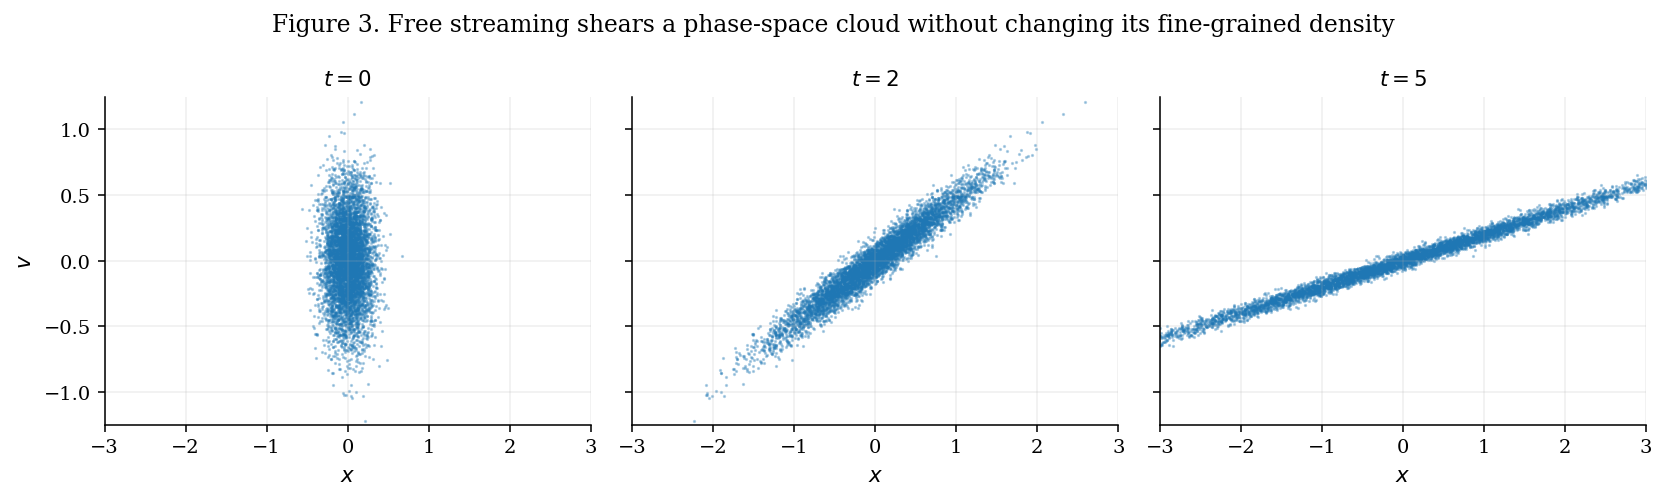

In [4]:
np.random.seed(4)

N = 6000
x0 = np.random.normal(0.0, 0.16, N)
v0 = np.random.normal(0.0, 0.30, N)

times = [0.0, 2.0, 5.0]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, sharey=True)

for ax, t in zip(axes, times):
    x = x0 + v0 * t
    ax.scatter(x, v0, s=0.45, alpha=0.35, rasterized=True)
    ax.set_title(rf"$t={t:g}$")
    ax.set_xlabel(r"$x$")
    ax.grid(alpha=0.2)

axes[0].set_ylabel(r"$v$")
axes[0].set_xlim(-3.0, 3.0)
axes[0].set_ylim(-1.25, 1.25)

fig.suptitle("Figure 3. Free streaming shears a phase-space cloud without changing its fine-grained density")
fig.tight_layout()
plt.show()


**Figure 3. Free streaming and phase-space shear**

Figure 3 illustrates collisionless transport in the absence of forces,

$$
\frac{dx}{dt}=v,\qquad \frac{dv}{dt}=0.
$$

Particle velocities remain constant, while positions evolve according to

$$
x(t)=x_0+vt.
$$

The initially localized cloud is therefore sheared in phase space: particles with larger positive velocity move to increasing $x$, while those with negative velocity move oppositely.

The occupied region changes shape but not fine-grained phase-space area. This is the transport geometry underlying Liouville’s theorem and the collisionless Vlasov description.

The figure also indicates why numerical resolution is important. Smooth initial data develop increasingly fine filamentary structure under advection, so excessive numerical diffusion can suppress physically relevant phase-space evolution.

## References

[1] F. F. Chen, *Introduction to Plasma Physics and Controlled Fusion*, 3rd ed., Springer, 2016.

[2] D. R. Nicholson, *Introduction to Plasma Theory*, Wiley, 1983.

[3] N. A. Krall and A. W. Trivelpiece, *Principles of Plasma Physics*, McGraw-Hill, 1973.

[4] T. H. Stix, *Waves in Plasmas*, American Institute of Physics, 1992.

[5] C. K. Birdsall and A. B. Langdon, *Plasma Physics via Computer Simulation*, CRC Press, 2004.

[6] M. W. Kunz, *Lecture Notes on Introduction to Plasma Astrophysics*, Princeton University.

[7] W. W. Lee, *Vlasov-Poisson Equations; Particle Codes; Klimontovich Representation*, Princeton Plasma Physics Laboratory lecture notes. 
